# Curso: Redes Neurais para Processamento de Linguagem Natural

Prof. [Denilson Alves Pereira](https://sites.google.com/ufla.br/denilsonpereira) <br>
Departamento de Ciência da Computação (DCC) <br>
Instituto de Ciências Exatas e Tecnológicas (ICET) <br> 
Universidade Federal de Lavras (UFLA)

## Classificação de Texto usando uma Rede Neural Recorrente (RNN)

Objetivo: apresentar um exemplo de uso de uma Rede Neural Recorrente para classificação de texto.

Você vai aprender a:
- Usar as bibliotecas de Redes Neurais Recorrentes
- Configurar uma arquitetura usando camadas LSTM biderecionais
- Treinar um modelo de PLN para classificação de sentimentos
- Avaliar o modelo treinado

Referências: <br>
O código do exemplo foi obtido de: <br>
https://www.tensorflow.org/text/tutorials/text_classification_rnn <br>
Documentação da API Keras para Camadas Recorrentes:<br>
https://keras.io/api/layers/recurrent_layers/<br>
https://www.tensorflow.org/guide/keras/working_with_rnns<br>

Versão: Fevereiro, 2024

### Pacotes

In [1]:
# Instala bibliotecas, se necessário
#!pip install tensorflow_datasets

In [2]:
import numpy as np
import tensorflow_datasets as tfds
import tensorflow as tf
import matplotlib.pyplot as plt

tfds.disable_progress_bar()

2024-02-26 10:49:20.888495: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2024-02-26 10:49:21.316158: E tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:9342] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-02-26 10:49:21.316225: E tensorflow/compiler/xla/stream_executor/cuda/cuda_fft.cc:609] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-02-26 10:49:21.318644: E tensorflow/compiler/xla/stream_executor/cuda/cuda_blas.cc:1518] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2024-02-26 10:49:21.505220: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2024-02-26 10:49:21.507390: I tensorflow/core/platform/cpu_feature_guard.cc:182] This Tens

### Função para plotar gráficos

In [3]:
def plot_graphs(history, metric):
  plt.plot(history.history[metric])
  plt.plot(history.history['val_'+metric], '')
  plt.xlabel("Epochs")
  plt.ylabel(metric)
  plt.legend([metric, 'val_'+metric])

### Dataset

IMDB - dataset de revisão de filmes, rotulado para classificação binária: sentimento positivo ou negativo.

In [4]:
dataset, info = tfds.load('imdb_reviews', with_info=True, as_supervised=True)
train_dataset, test_dataset = dataset['train'], dataset['test']

train_dataset.element_spec

2024-02-26 10:49:36.368362: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:894] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2024-02-26 10:49:36.613094: W tensorflow/core/common_runtime/gpu/gpu_device.cc:2211] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


(TensorSpec(shape=(), dtype=tf.string, name=None),
 TensorSpec(shape=(), dtype=tf.int64, name=None))

In [5]:
# Retorna uma amostra do dataset de treino. Par: texto, rótulo
for example, label in train_dataset.take(1):
  print('text: ', example.numpy())
  print('label: ', label.numpy())

text:  b"This was an absolutely terrible movie. Don't be lured in by Christopher Walken or Michael Ironside. Both are great actors, but this must simply be their worst role in history. Even their great acting could not redeem this movie's ridiculous storyline. This movie is an early nineties US propaganda piece. The most pathetic scenes were those when the Columbian rebels were making their cases for revolutions. Maria Conchita Alonso appeared phony, and her pseudo-love affair with Walken was nothing but a pathetic emotional plug in a movie that was devoid of any real meaning. I am disappointed that there are movies like this, ruining actor's like Christopher Walken's good name. I could barely sit through it."
label:  0


2024-02-26 10:49:38.409185: W tensorflow/core/kernels/data/cache_dataset_ops.cc:854] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.


Embaralha os dados de treinamento <br>
Cria batches (lotes) para os pares texto, rótulo

In [6]:
BUFFER_SIZE = 10000
BATCH_SIZE = 64

In [7]:
train_dataset = train_dataset.shuffle(BUFFER_SIZE).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
test_dataset = test_dataset.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

In [8]:
for example, label in train_dataset.take(1):
  print('texts: ', example.numpy()[:3])
  print()
  print('labels: ', label.numpy()[:3])

texts:  [b'Definitely one of funny man Eddie Murphy\'s lesser films is this nonsense about a kidnapped mystical child, three hundred year old dragons and a "Chosen One".<br /><br />Murphy is the "Chosen One" in question, and as the opening song suggests, he is "the best man in the world". A finder of lost and missing children, he is approached by a mysterious Tibetan woman (Charlotte Lewis) who tells him he is "The Chosen One", and that it is his destiny to find and rescue "The Golden Child". For if the child were to die, compassion would die with him, as he is the bearer of compassion.<br /><br />If all this hocus pocus rubbish hasn\'t ruined it for you now, it surely will once the movie begins. Suffice to say the plot is abominable and destroys the whole film. Meant to be another vehicle for Murphy\'s egotistical brand of humour (the comedy isn\'t so great mind you), the movie fails on many levels. Even Charles Dance as the evil Sardo Numspa can\'t do much for proceedings. Very silly

2024-02-26 10:49:42.470911: W tensorflow/core/kernels/data/cache_dataset_ops.cc:854] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.


### Codificação (Encoder) do Texto

O texto bruto carregado pelo tfds necessita ser processado antes que ele possa ser usado em um modelo. A forma mais simples de processar o texto para treinamento é usar a camada *TextVectorization*. Essa camada tem muitas capacidades, mas aqui usaremos o seu comportamento padrão.

Cria a camada e passa o texto do dataset para seu método *.adapt*.

In [9]:
VOCAB_SIZE = 1000
encoder = tf.keras.layers.TextVectorization(max_tokens=VOCAB_SIZE)
encoder.adapt(train_dataset.map(lambda text, label: text))

O método *.adapt* define o vocabulário da camada.<br>
Listamos abaixo os primeiros 20 tokens, ordenados por frequência, exceto os dois primeiros, que são o token de preenchimento (*padding*) e token desconhecido (*unknown*)

In [10]:
vocab = np.array(encoder.get_vocabulary())
vocab[:20]

array(['', '[UNK]', 'the', 'and', 'a', 'of', 'to', 'is', 'in', 'it', 'i',
       'this', 'that', 'br', 'was', 'as', 'for', 'with', 'movie', 'but'],
      dtype='<U14')

Uma vez que o vocabulário é definido, a camada pode codificar o texto em índices. Os tensores de índices são preenchidos com zeros (*0-padded*) para a sequência mais longa no batch (a menos que você defina um valor fixo para *output_sequence_length*.

In [11]:
encoded_example = encoder(example)[:3].numpy()
encoded_example

array([[387,  29,   5, ...,   0,   0,   0],
       [ 10,  67, 284, ...,   0,   0,   0],
       [287, 390,  16, ...,   0,   0,   0]])

Com a configuração padrão, o processo não é completamente reversível. As principais razões são:
- O valor padrão para *preprocessing.TextVectorization* é "lower_and_strip_punctuation".
- O tamanho limitado do vocabulário e a falta de alternativa baseada em caracteres resultam em alguns tokens desconhecidos.

In [12]:
for n in range(3):
  print("Original: ", example[n].numpy())
  print("Round-trip: ", " ".join(vocab[encoded_example[n]]))
  print()

Original:  b'Definitely one of funny man Eddie Murphy\'s lesser films is this nonsense about a kidnapped mystical child, three hundred year old dragons and a "Chosen One".<br /><br />Murphy is the "Chosen One" in question, and as the opening song suggests, he is "the best man in the world". A finder of lost and missing children, he is approached by a mysterious Tibetan woman (Charlotte Lewis) who tells him he is "The Chosen One", and that it is his destiny to find and rescue "The Golden Child". For if the child were to die, compassion would die with him, as he is the bearer of compassion.<br /><br />If all this hocus pocus rubbish hasn\'t ruined it for you now, it surely will once the movie begins. Suffice to say the plot is abominable and destroys the whole film. Meant to be another vehicle for Murphy\'s egotistical brand of humour (the comedy isn\'t so great mind you), the movie fails on many levels. Even Charles Dance as the evil Sardo Numspa can\'t do much for proceedings. Very sil

### Modelo de Classificação

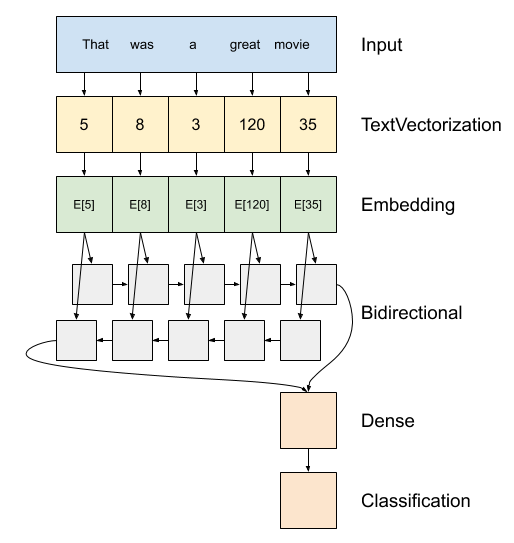

1. O modelo pode ser criado como um *tf.keras.Sequential*.
2. A primeira camada é o *encoder*, que converte o texto para uma sequência de índices de tokens.
3. Depois do *encoder* está a camada de *embedding*. Uma cada de *embedding* armazena um vetor por palavra. Quando chamada, ela converte as sequências de índices de palavras em sequências de vetores. Esses vetores são treináveis. Depois de treinados (com dados suficientes), palavras com significados similares frequentemente têm vetores similares. Esse esquema é mais eficiente do que a operação equivalente de se criar um vetor *one-hot encoded* por meio da camada *tf.keras.layers.Dense*.
4. A Rede Neural Recorrente (RNN) processa uma sequência de entrada por meio da iteração dos elementos. RNNs passam a saída de um passo de tempo (*timestep*) para sua entrada no próximo *timestep*. O *wrapper* *tf.keras.layers.Bidirectional* também pode ser usado com uma camada RNN. Isso propaga a entrada para frente e para trás na camada RNN e então concatena a saída final. Nós usamos aqui uma camada LSTM (Long Short-Term Memory).
   - A principal vantagem de uma RNN bidirecional é que o sinal desde o início da entrada não necessita ser processado em cada intervalo de tempo para afetar a saída.
   - A principal desvantagem de uma RNN bidirecional é que você não pode transmitir previsões com eficiência à medida que palavras são adicionadas ao final.
6. Depois que a RNN converte a sequência em um único vetor, as duas camadas densas fazem algum processamento final e convertem essa representação vetorial em um único logit como saída da classificação.

In [13]:
model = tf.keras.Sequential([
    encoder,
    tf.keras.layers.Embedding(
        input_dim=len(encoder.get_vocabulary()),
        output_dim=64,
        # Use masking to handle the variable sequence lengths
        mask_zero=True),
    tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(64)),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(1)
])

Compila o modelo Keras para configurar o processo de treinamento

In [14]:
model.compile(loss=tf.keras.losses.BinaryCrossentropy(from_logits=True),
              optimizer=tf.keras.optimizers.Adam(1e-4),
              metrics=['accuracy'])

### Treinamento do Modelo

In [15]:
history = model.fit(train_dataset, epochs=10,
                    validation_data=test_dataset,
                    validation_steps=30)

Epoch 1/10
391/391 [==============================] - 222s 552ms/step - loss: 0.6432 - accuracy: 0.5769 - val_loss: 0.5363 - val_accuracy: 0.6708
Epoch 2/10


2024-02-26 10:53:41.839192: W tensorflow/core/kernels/data/cache_dataset_ops.cc:854] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.


391/391 [==============================] - 214s 546ms/step - loss: 0.4010 - accuracy: 0.8135 - val_loss: 0.3757 - val_accuracy: 0.8333
Epoch 3/10


2024-02-26 10:57:15.508262: W tensorflow/core/kernels/data/cache_dataset_ops.cc:854] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.


391/391 [==============================] - 215s 550ms/step - loss: 0.3400 - accuracy: 0.8494 - val_loss: 0.3525 - val_accuracy: 0.8516
Epoch 4/10


...

2024-02-26 11:19:27.494018: W tensorflow/core/kernels/data/cache_dataset_ops.cc:854] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.


391/391 [==============================] - 217s 556ms/step - loss: 0.3016 - accuracy: 0.8714 - val_loss: 0.3237 - val_accuracy: 0.8500
Epoch 10/10


2024-02-26 11:23:04.720486: W tensorflow/core/kernels/data/cache_dataset_ops.cc:854] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.


391/391 [==============================] - 219s 560ms/step - loss: 0.2987 - accuracy: 0.8711 - val_loss: 0.3183 - val_accuracy: 0.8578


2024-02-26 11:26:43.600101: W tensorflow/core/kernels/data/cache_dataset_ops.cc:854] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.


### Avaliação do Modelo no Conjunto de Dados de Teste

In [16]:
test_loss, test_acc = model.evaluate(test_dataset)

print('Test Loss:', test_loss)
print('Test Accuracy:', test_acc)

391/391 [==============================] - 67s 170ms/step - loss: 0.3139 - accuracy: 0.8623
Test Loss: 0.3139062523841858
Test Accuracy: 0.862280011177063


Plota gráficos de acurácia e perda

(0.0, 0.6604632139205933)

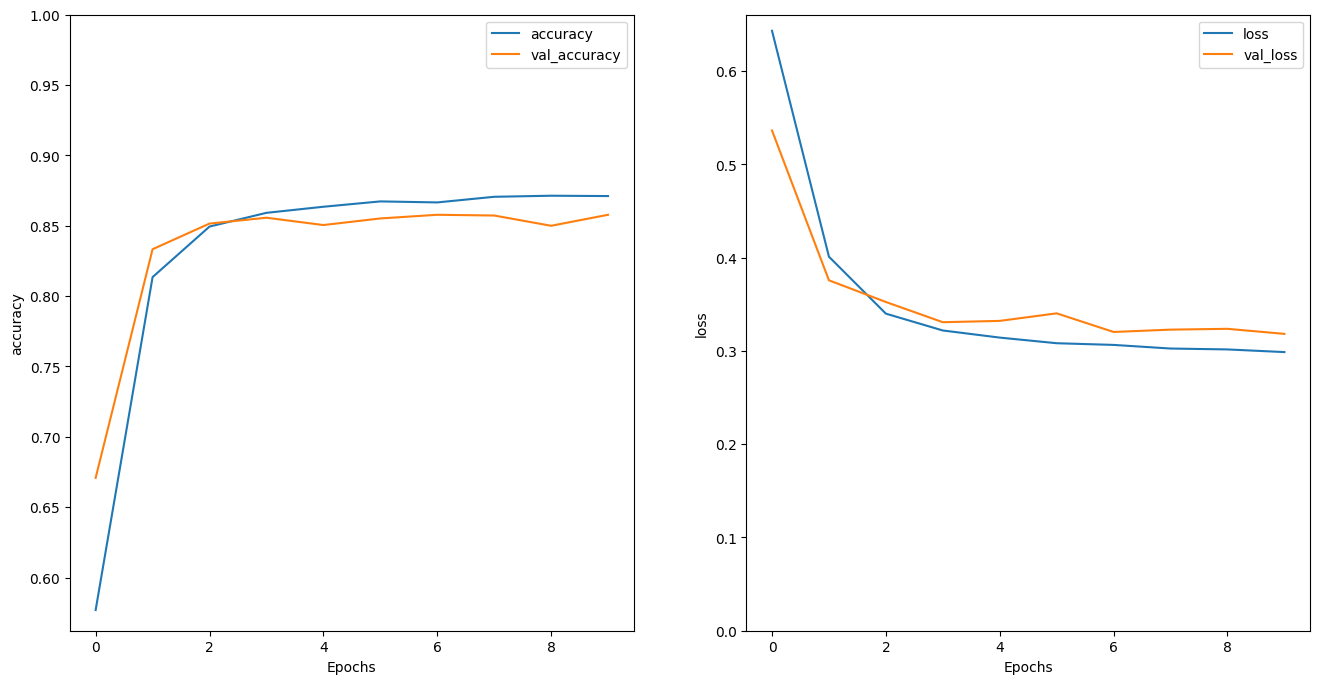

In [17]:
plt.figure(figsize=(16, 8))
plt.subplot(1, 2, 1)
plot_graphs(history, 'accuracy')
plt.ylim(None, 1)
plt.subplot(1, 2, 2)
plot_graphs(history, 'loss')
plt.ylim(0, None)

### Predição de uma Nova Sentença

Se a predição for >= 0.0, então ela é positiva, caso contrário, ela é negativa

In [18]:
sample_text = ('The movie was cool. The animation and the graphics '
               'were out of this world. I would recommend this movie.')
predictions = model.predict(np.array([sample_text]))
print(predictions)

1/1 [==============================] - 2s 2s/step
[[0.73384535]]


### Pilha de Camadas LSTM

Em uma arquitetura de Redes Neurais Recorrentes, várias camadas podem ser empilhadas para produzir o resultado final. Nesse caso, a saída de cada *timestep* é conectada na entrada do *timestep* da camada acima.

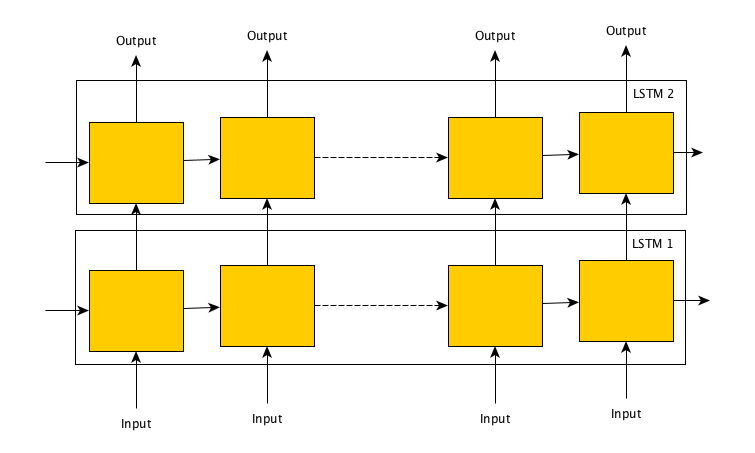

As camadas recorrentes Keras têm dois modos disponíveis que são controlados pelo argumento *return_sequences*:
- Se False, ele retorna somente a última saída para cada sequência de entrada (um tensor 2D na forma *(batch_size, output_features)*). Esse é o modo padrão, usado no modelo anterior.
- Se True, a sequência completa de saídas sucessivas para cada *timestep* é retornada (um tensor 3D na forma *(batch_size, timesteps, output_features)*).

O fluxo de informação para uma camada com *return_sequences=True* se parece com o desenho abaixo:

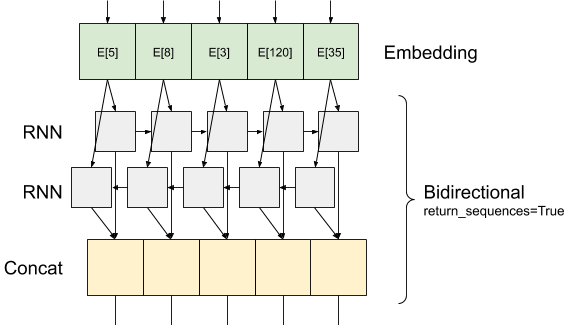

In [19]:
model = tf.keras.Sequential([
    encoder,
    tf.keras.layers.Embedding(len(encoder.get_vocabulary()), 64, mask_zero=True),
    tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(64,  return_sequences=True)),
    tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(32)),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(1)
])

In [20]:
model.compile(loss=tf.keras.losses.BinaryCrossentropy(from_logits=True),
              optimizer=tf.keras.optimizers.Adam(1e-4),
              metrics=['accuracy'])

In [21]:
history = model.fit(train_dataset, epochs=10,
                    validation_data=test_dataset,
                    validation_steps=30)

Epoch 1/10
391/391 [==============================] - 452s 1s/step - loss: 0.6134 - accuracy: 0.6036 - val_loss: 0.4395 - val_accuracy: 0.8135
Epoch 2/10
391/391 [==============================] - 1085s 3s/step - loss: 0.3896 - accuracy: 0.8266 - val_loss: 0.3783 - val_accuracy: 0.8141
Epoch 3/10
391/391 [==============================] - 1360s 3s/step - loss: 0.3579 - accuracy: 0.8442 - val_loss: 0.3586 - val_accuracy: 0.8234
Epoch 4/10
391/391 [==============================] - 462s 1s/step - loss: 0.3326 - accuracy: 0.8543 - val_loss: 0.3410 - val_accuracy: 0.8458
Epoch 5/10
391/391 [==============================] - 453s 1s/step - loss: 0.3206 - accuracy: 0.8634 - val_loss: 0.3289 - val_accuracy: 0.8479
Epoch 6/10
391/391 [==============================] - 445s 1s/step - loss: 0.3160 - accuracy: 0.8645 - val_loss: 0.3236 - val_accuracy: 0.8573
Epoch 7/10
391/391 [==============================] - 448s 1s/step - loss: 0.3076 - accuracy: 0.8676 - val_loss: 0.3216 - val_accuracy: 0.85

In [22]:
test_loss, test_acc = model.evaluate(test_dataset)

print('Test Loss:', test_loss)
print('Test Accuracy:', test_acc)

391/391 [==============================] - 130s 332ms/step - loss: 0.3190 - accuracy: 0.8617
Test Loss: 0.3190199136734009
Test Accuracy: 0.8616799712181091


In [23]:
# predict on a sample text without padding.

sample_text = ('The movie was not good. The animation and the graphics '
               'were terrible. I would not recommend this movie.')
predictions = model.predict(np.array([sample_text]))
print(predictions)

1/1 [==============================] - 4s 4s/step
[[-1.5189592]]


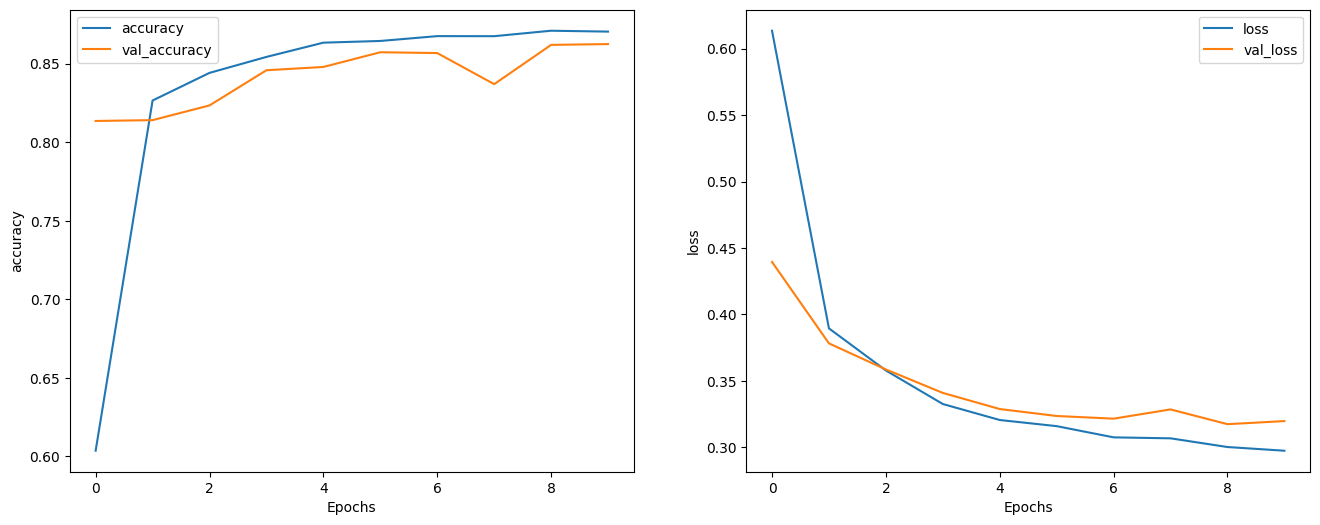

In [24]:
plt.figure(figsize=(16, 6))
plt.subplot(1, 2, 1)
plot_graphs(history, 'accuracy')
plt.subplot(1, 2, 2)
plot_graphs(history, 'loss')

# Fim

Esse notebook apresentou um exemplo de uso de uma Rede Neural Recorrente para classificação de texto. Você aprendeu a usar as bibliotecas de Redes Neurais Recorrentes, configurar uma arquitetura usando camadas LSTM biderecionais, treinar um modelo de PLN para classificação de sentimentos, avaliar o modelo treinado e predizer novas sentenças de entrada.

-------------------------------------------